In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Задачи

## Теоретические задачи

### Задача 1. Принадлежность пустого множества и дополнение $\sigma$-алгебре

Показать, что $\varnothing$ лежит в любой $\sigma$-алгебре событий, а также если $A\in\mathcal F$, то $\overline A \in \mathcal F$.


### Задача 2. Натуральные числа и сигма-алгебра

Рассмотрим пространство элементарных исходов

$$\Omega=\mathbb N$$

и систему множеств

$$\mathcal A=\{B\subseteq\mathbb N: |B|<\infty \text{ или } |\overline B|<\infty\}$$

То есть $\mathcal A$ состоит из всех конечных подмножеств $\mathbb N$ и всех множеств с конечным дополнением.

 1. Проверь, что данное множество является алгеброй
 2. Проверь, что данное множество не является $\sigma$-алгеброй

### Задача 3. Сигма алгебра из двух множеств

Пусть заданы множества
 - $A:A\neq \varnothing,A\neq \Omega,$
 - $B:B \neq \varnothing, B \neq \Omega, B \neq A , B \neq \overline{A}$.

Является ли $\{\varnothing, \Omega, A, B, \overline{A}, \overline{B}\}$ алгеброй событий?


### Задача 4. Открытые и замкнутые множества в борелевской сигма-алгебре

Показать, что в борелевской $\sigma$-алгебре лежат:
 - Открытые множества
 - Замкнутые множества


### Задача 5. Мера множества иррациональных и не комплексных точек

 - $X=[0,1]\setminus\mathbb Q$ — множество иррациональных точек отрезка $[0,1]$.

   Найди $\mu_L(X)$.

 - Пусть $C\subseteq[0,1]$ — счётное множество.

   Найди меру Лебега множества $Y = [0,1]\setminus C$. Объяснить, почему множество $[0,1]\setminus C$ имеет полную меру в $[0,1]$.







## Задача. Сигма-алгебра, python и продукт

Команда продукта запустила A/B-тест новой версии лендинга. Каждый пользователь случайно попадает в вариант `A` или `B`.

Для каждого пользователя фиксируются данные:

- `user_id` — идентификатор пользователя;
- `variant` — версия лендинга: `A` или `B`;
- `viewed` — пользователь увидел лендинг;
- `clicked` — пользователь нажал на основную кнопку;
- `registered` — пользователь зарегистрировался;
- `paid` — пользователь оплатил;
- `revenue` — сумма оплаты в рублях.

Одна строка таблицы соответствует одному пользователю.

**Задания**:

  0. Создай датафрейм с имитацией данных выше.

  1. Опиши элементарный исход $\omega$ для одного пользователя.

  2. Предложи конечное пространство исходов $\Omega$, если учитывать только признаки `variant`, `clicked`, `registered`, `paid`.

  3. Создай маски для следующих событий:

      - $A=\{\text{пользователь попал в вариант B}\}$

      - $C=\{\text{пользователь кликнул}\}$

      - $R=\{\text{пользователь зарегистрировался}\}$

      - $P=\{\text{пользователь оплатил}\}$

  4. Создай датафрейм с частотами и частостями (по столбцам) следующих событий (по строкам):

      - Пользователь кликнул, но не оплатил

      - Пользователь зарегистрировался и оплатил

      - Пользователь либо кликнул, либо зарегистрировался

      - Пользователь попал в вариант `B` и оплатил

  5. Введи случайные величины:

      - $X(\omega)=clicked$

      - $Y(\omega)=paid$

      - $Z(\omega)=revenue$

  Объясни, почему это случайные величины.

  6. Рассчитай эмпирические вероятности:

      - $\mathbb P(C)$

      - $\mathbb P(R)$

      - $\mathbb P(P)$

      - $\mathbb P(P \mid C)$

  7. Проверь на данных равенство:
  $\mathbb P(C \cup P)=\mathbb P(C)+\mathbb P(P)-\mathbb P(C \cap P)$

  8. Переложи описанное распределение на формализованный язык аксиоматики вероятностей.



## Задача. Python и манипуляция с выборками

Создадим алгоритм, который будет по требованию завышать или, наоборот, занижать выборку по сравнению с генеральной совокупностью.


**Описание данных:**
  - **id** - уникальный идентификатор клиента.
  - **is_loyal** - флаг принадлежности к сегменту лояльных пользователей.
  - **is_premium** - флаг принадлежности к сегменту премиальных пользователей.
  - **CNT paid** - количество оплат клиентом.


In [ ]:
df = pd.read_excel('https://raw.githubusercontent.com/zalig/cu-datasets/main/04_purchase.xlsx')
df.head(2)

,id,is_loyal,is_premium,CNT Paid
0,101,0,0,2
1,102,0,1,5


In [ ]:
df.groupby(['is_loyal','is_premium'])[['CNT Paid']].mean()

### Видим, что лояльность и премиальность увеличивают среднее кол-во покупок.

CNT Paid
is_loyal is_premium           
0        0            3.533465
         1            7.891892
1        0            7.070845
         1           11.890110

In [ ]:
df.groupby(['is_loyal','is_premium'])[['CNT Paid']].count()

### Видим количество клиентов в каждом сегменте — наибольшее кол-во не являются ни лояльными, ни премиальными клиентами.

CNT Paid
is_loyal is_premium          
0        0               1016
         1                296
1        0                367
         1                 91

### Этап 1. Выборка без учёта сегментов

Теперь извлечём выборку так, чтобы выборка была **гарантированно лучше** генеральной совокупности.

In [ ]:
### Твой код здесь


### Этап 2. Выборка с нужными результатами на каждом сегменте

Сформируем выборку так, чтобы среднее количество совершённых операций в выборке было выше, чем в генеральной совокупности, среди каждой категории *лояльности* (1 vs 0) и *премиальности* (1 vs 0).

In [ ]:
### Твой код здесь


### Этап 3. Выборка с нужными результатами и пропорциями на каждом сегменте

Решим предыдущий пункт так, чтобы внутри выборки соотношение доли лояльных и нелояльных клиентов было таким же, как в генеральной совокупности.

In [ ]:
### Твой код здесь


## Задача. FinTech. Анализ сумм транзакций

Ты работаешь аналитиком в отделе рисков банка. Задача заключается в изучении структуры онлайн-переводов клиентов за сутки ($n=1000$).

Суммы транзакций — это непрерывные данные с огромным разбросом и редкими, но крупными переводами (выбросами).

 1. Импортируй данные из файла `base_transactions.txt`;
 2. Выбери кол-во бинов с помощью Стерджесса и Фридмана-Дьякони;
 3. Построй две гистограммы, используя результаты предыдущего пункта;
 4. Построй боксплот;
 5. Построй интервальный ряд;
 6. Визуализируй полигон частот;
 7. Визуализируй кумуляту и огиву;



In [ ]:
### Твоё решение здесь


# Ответ

## Теоретические задачи

### Задача 1. Принадлежность пустого множества и дополнение $\sigma$-алгебре

Показать, что $\varnothing$ лежит в любой $\sigma$-алгебре событий, а также если $A\in\mathcal F$, то $\overline A \in \mathcal F$.


**Решение**



Пусть $\mathcal F$ — $\sigma$-алгебра на пространстве элементарных исходов $\Omega$.

По определению $\sigma$-алгебры:

$$\Omega \in \mathcal F$$

Также $\sigma$-алгебра замкнута относительно разности множеств. Значит, если $B,C\in\mathcal F$, то

$$B\setminus C\in\mathcal F$$

Возьмём $B=C=\Omega$. Тогда

$$\Omega\setminus\Omega=\varnothing$$

Следовательно,

$$\varnothing\in\mathcal F$$

Теперь пусть $A\in\mathcal F$. Так как $\Omega\in\mathcal F$ и $\mathcal F$ замкнута относительно разности, то

$$\Omega\setminus A\in\mathcal F$$

Но

$$\Omega\setminus A=\overline A$$

Поэтому

$$\overline A\in\mathcal F$$


**Вывод**

В любой $\sigma$-алгебре лежит пустое множество, а вместе с любым событием $A$ лежит и его дополнение $\overline A$.

### Задача 2. Натуральные числа и сигма-алгебра

Рассмотрим пространство элементарных исходов

$$\Omega=\mathbb N$$

и систему множеств

$$\mathcal A=\{B\subseteq\mathbb N: |B|<\infty \text{ или } |\overline B|<\infty\}$$

То есть $\mathcal A$ состоит из всех конечных подмножеств $\mathbb N$ и всех множеств с конечным дополнением.

 1. Проверь, что данное множество является алгеброй
 2. Проверь, что данное множество не является $\sigma$-алгеброй

**Решение**





**Проверим, что это алгебра**

Во-первых,

$$\Omega\in\mathcal A$$

потому что дополнение к $\Omega$ пусто:

$$\overline\Omega=\varnothing$$

а $\varnothing$ — конечное множество.

Во-вторых, система $\mathcal A$ замкнута относительно конечных операций: объединения, пересечения и разности. Действительно, при конечных объединениях и пересечениях конечные множества остаются конечными, а множества с конечным дополнением снова дают множества такого же типа.

Значит, $\mathcal A$ — алгебра.

**Покажем, что это не $\sigma$-алгебра**

Пусть

$$A_i=\{2i\},\quad i\in\mathbb N$$

Каждое множество $A_i$ конечно, поэтому

$$A_i\in\mathcal A$$

Но счётное объединение этих множеств равно множеству чётных натуральных чисел:

$$\bigcup_{i=1}^{\infty}A_i=2\mathbb N$$

Множество $2\mathbb N$ не является конечным. Его дополнение — множество нечётных натуральных чисел — тоже не является конечным. Поэтому

$$2\mathbb N\notin\mathcal A$$

Значит, $\mathcal A$ не замкнута относительно счётного объединения.


**Вывод**

$$\mathcal A=\{B\subseteq\mathbb N: |B|<\infty \text{ или } |\overline B|<\infty\}$$

является алгеброй, но не является $\sigma$-алгеброй.

### Задача 3. Сигма алгебра из двух множеств

Пусть заданы множества
 - $A:A\neq \varnothing,A\neq \Omega,$
 - $B:B \neq \varnothing, B \neq \Omega, B \neq A , B \neq \overline{A}$.

Является ли $\{\varnothing, \Omega, A, B, \overline{A}, \overline{B}\}$ алгеброй событий?


**Решение**


Если система является алгеброй, то возможны $3$ случая:

 1. $A\cap B=\varnothing$. Тогда $A \cup B \neq A$, т.к. $B \neq \varnothing$; $A \cup B \neq B$, т.к. $A \neq \varnothing$; $A \cup B \neq \Omega$, т.к. $B \neq \overline{A}$; $A \cup B \neq \varnothing$, т.к. $B \neq \varnothing$; $A \cup B \neq \overline{A}$, т.к. $A \neq \varnothing$; $A \cup B \neq \overline{B}$, т.к. $B \neq \varnothing$ (противоречие).

 2.  $A\cap B=A, A\subset B$. Тогда $A \cup \overline{B} \neq A$, т.к. $\overline{B} \neq \varnothing$; $A \cup \overline{B} \neq B$, т.к. $A \neq B$; $A \cup \overline{B} \neq \Omega$, т.к. $A \subset B$; $A \cup B \neq \varnothing$, т.к. $A \neq \varnothing$; $A \cup \overline{B} \neq \overline{A}$, т.к. $A \neq \varnothing$; $A \cup \overline{B} \neq \overline{B}$, т.к. $A\subset B$ (противоречие).

 3. $A\cap B=B, B\subset A$ невозможен аналогично случаю (ii) (противоречие).

Значит $\{\varnothing, \Omega, A,B, \overline{A},\overline{B}\}$ не является алгеброй событий.


### Задача 4. Открытые и замкнутые множества в борелевской сигма-алгебре

Показать, что в борелевской $\sigma$-алгебре лежат:
 - Открытые множества
 - Замкнутые множества


**Решение**



По определению борелевская $\sigma$-алгебра на $\mathbb R$ содержит все открытые интервалы.

Нужно показать, что она содержит произвольные открытые и замкнутые множества.

**Открытые множества**

Любое открытое множество $G\subseteq\mathbb R$ можно представить как не более чем счётное объединение открытых интервалов:

$$G=\bigcup_{k=1}^{\infty}(a_k,b_k)$$

Каждый интервал $(a_k,b_k)$ лежит в $\mathcal B(\mathbb R)$.

Так как $\mathcal B(\mathbb R)$ — это $\sigma$-алгебра, она замкнута относительно счётных объединений. Поэтому

$$G\in\mathcal B(\mathbb R)$$

**Замкнутые множества**

Пусть $F\subseteq\mathbb R$ — замкнутое множество. Тогда его дополнение открыто:

$$\overline F=\mathbb R\setminus F$$

Так как $\overline F$ открыто, то

$$\overline F\in\mathcal B(\mathbb R)$$

А $\sigma$-алгебра замкнута относительно дополнения. Следовательно,

$$F\in\mathcal B(\mathbb R)$$


**Вывод**

Все открытые и все замкнутые множества на прямой лежат в борелевской $\sigma$-алгебре.

### Задача 5. Мера множества иррациональных и не комплексных точек

 - $X=[0,1]\setminus\mathbb Q$ — множество иррациональных точек отрезка $[0,1]$.

   Найди $\mu_L(X)$.

 - Пусть $C\subseteq[0,1]$ — счётное множество.

   Найди меру Лебега множества $Y = [0,1]\setminus C$. Объяснить, почему множество $[0,1]\setminus C$ имеет полную меру в $[0,1]$.







**Решение**


**Пункт 1**

Отрезок $[0,1]$ можно разложить на рациональные и иррациональные точки:

$$[0,1]=([0,1]\cap\mathbb Q)\sqcup X$$

Здесь объединение дизъюнктное.

Множество рациональных чисел на отрезке $[0,1]$ счётно:

$$[0,1]\cap\mathbb Q=\{q_1,q_2,q_3,\ldots\}$$

Мера одной точки равна нулю:

$$\mu_L(\{q_i\})=0$$

Поэтому по счётной аддитивности

$$\mu_L([0,1]\cap\mathbb Q)=\sum_{i=1}^{\infty}\mu_L(\{q_i\})=0$$

Так как

$$\mu_L([0,1])=1$$

получаем

$$1=\mu_L([0,1])=\mu_L([0,1]\cap\mathbb Q)+\mu_L(X)=0+\mu_L(X)$$

Следовательно,

$$\mu_L(X)=1$$


**Пункт 2**

Так как множество $C$ счётно, его можно представить в виде $C={c_1,c_2,c_3,\ldots}$.

Мера Лебега каждой отдельной точки равна нулю: $\mu_L({c_i})=0$.

По счётной аддитивности меры

$$\mu_L(C)=\mu_L\left(\bigsqcup_{i=1}^{\infty}{c_i}\right)=\sum_{i=1}^{\infty}\mu_L({c_i})=0.$$

Множества $C$ и $[0,1]\setminus C$ не пересекаются, а их объединение равно всему отрезку:

$$[0,1]=C\sqcup\bigl([0,1]\setminus C\bigr).$$

Следовательно,

$$\mu_L([0,1])=\mu_L(C)+\mu_L([0,1]\setminus C).$$

Так как $\mu_L([0,1])=1$ и $\mu_L(C)=0$, получаем

$$1=0+\mu_L([0,1]\setminus C).$$

Следовательно,

$$\mu_L([0,1]\setminus C)=1.$$

**Вывод**

Множество $[0,1]\setminus C$ имеет полную меру в $[0,1]$, поскольку его дополнение относительно $[0,1]$ имеет меру ноль.

Иными словами, почти все точки отрезка $[0,1]$ не принадлежат множеству $C$.


**Вывод**

Мера множества иррациональных точек на $[0,1]$ равна $1$.

## Задача. Сигма-алгебра, python и продукт

Команда продукта запустила A/B-тест новой версии лендинга. Каждый пользователь случайно попадает в вариант `A` или `B`.

Для каждого пользователя фиксируются данные:

- `user_id` — идентификатор пользователя;
- `variant` — версия лендинга: `A` или `B`;
- `viewed` — пользователь увидел лендинг;
- `clicked` — пользователь нажал на основную кнопку;
- `registered` — пользователь зарегистрировался;
- `paid` — пользователь оплатил;
- `revenue` — сумма оплаты в рублях.

Одна строка таблицы соответствует одному пользователю.

**Задания**:

  0. Создай датафрейм с имитацией данных выше.

  1. Опиши элементарный исход $\omega$ для одного пользователя.

  2. Предложи конечное пространство исходов $\Omega$, если учитывать только признаки `variant`, `clicked`, `registered`, `paid`.

  3. Создай маски для следующих событий:

      - $A=\{\text{пользователь попал в вариант B}\}$

      - $C=\{\text{пользователь кликнул}\}$

      - $R=\{\text{пользователь зарегистрировался}\}$

      - $P=\{\text{пользователь оплатил}\}$

  4. Создай датафрейм с частотами и частостями (по столбцам) следующих событий (по строкам):

      - Пользователь кликнул, но не оплатил

      - Пользователь зарегистрировался и оплатил

      - Пользователь либо кликнул, либо зарегистрировался

      - Пользователь попал в вариант `B` и оплатил

  5. Введи случайные величины:

      - $X(\omega)=clicked$

      - $Y(\omega)=paid$

      - $Z(\omega)=revenue$

  Объясни, почему это случайные величины.

  6. Рассчитай эмпирические вероятности:

      - $\mathbb P(C)$

      - $\mathbb P(R)$

      - $\mathbb P(P)$

      - $\mathbb P(P \mid C)$

  7. Проверь на данных равенство:
  $\mathbb P(C \cup P)=\mathbb P(C)+\mathbb P(P)-\mathbb P(C \cap P)$

  8. Переложи описанное распределение на формализованный язык аксиоматики вероятностей.


**Решение**

### Пункт 0. Подготовка данных

Сначала создадим небольшой синтетический датасет A/B-теста. Он нужен только для того, чтобы на нём посчитать эмпирические вероятности событий.

Зафиксируем "рандом".

In [ ]:
np.random.seed(42)

Нам потребуется тысяча наблюдений.

In [ ]:
n = 1000

Создаём датафрейм:

 - *user_id* - идентикатор клиента от $1$ до $1000$.
 - *variant* - равномерное дискретное распределение между вариантами А и В.
 - *viewed* - всем проставляем единицу, так как все участвующие в эксперименте видели баннер.

In [ ]:
df = pd.DataFrame({
    "user_id": range(1, n + 1),
    "variant": np.random.choice(["A", "B"], size=n),
    "viewed": 1})

В группе А событие клика следует биномиальному распределению с параметром $0.28$, а в группе В - с параметром $0.34$.

In [ ]:
df["clicked"] = np.where(
    df["variant"] == "A",
    np.random.binomial(1, 0.28, size=n),
    np.random.binomial(1, 0.34, size=n))

Событие регистрации следует биномиальному распределению с параметром $0.15$ для тех, кто не кликал, и с параметром $0.5$ для тех, кто кликал.

In [ ]:
df["registered"] = np.random.binomial(1, 0.15 + 0.35 * df["clicked"], size=n)

Событие платежа так же зависит от события регистрации.

In [ ]:
df["paid"] = np.random.binomial(1, 0.08 + 0.25 * df["registered"], size=n)

In [ ]:
df["revenue"] = df["paid"] * np.random.choice(
    [500, 1000, 1500, 2000, 3000],
    size=n,
    p=[0.25, 0.30, 0.20, 0.15, 0.10])

df.head()

,user_id,variant,viewed,clicked,registered,paid,revenue
0,1,A,1,0,0,0,0
1,2,B,1,0,0,0,0
2,3,A,1,0,0,1,1000
3,4,A,1,1,1,0,0
4,5,A,1,0,0,0,0


### Пункт 1. Элементарный исход

Элементарный исход $\omega$ — это полное описание результата эксперимента для одного пользователя.

В этой задаче один исход можно записать так:

$$
\omega = (variant, viewed, clicked, registered, paid, revenue).
$$

Например:

$$
\omega = (B, 1, 1, 1, 0, 0).
$$

Это означает, что пользователь попал в вариант `B`, увидел лендинг, кликнул, зарегистрировался, но не оплатил.

### Пункт 2. Пространство элементарных исходов

Если учитывать только признаки `variant`, `clicked`, `registered`, `paid`, то элементарный исход имеет вид:

$$
\omega = (variant, clicked, registered, paid).
$$

Здесь:

$$
variant \in \{A, B\},
$$

$$
clicked \in \{0, 1\},
$$

$$
registered \in \{0, 1\},
$$

$$
paid \in \{0, 1\}.
$$

Тогда пространство исходов:

$$
\Omega =
\{A,B\}
\times
\{0,1\}
\times
\{0,1\}
\times
\{0,1\}.
$$

Всего в таком пространстве:

$$
2 \cdot 2 \cdot 2 \cdot 2 = 16
$$

элементарных исходов.

Создадим датафрейм со всеми возможными элементарными исходами (с помощью кортежа).

In [ ]:
omega = pd.DataFrame(
    [
        (variant, clicked, registered, paid)
        for variant in ["A", "B"]
        for clicked in [0, 1]
        for registered in [0, 1]
        for paid in [0, 1]
    ],
    columns=["variant", "clicked", "registered", "paid"]
)

omega

,variant,clicked,registered,paid
0,A,0,0,0
1,A,0,0,1
2,A,0,1,0
3,A,0,1,1
4,A,1,0,0
5,A,1,0,1
6,A,1,1,0
7,A,1,1,1
8,B,0,0,0
9,B,0,0,1


### Пункт 3. События

Событие — это подмножество пространства элементарных исходов.

В этой задаче можно записать:

$$
A = \{\omega \in \Omega: variant = B\},
$$

$$
C = \{\omega \in \Omega: clicked = 1\},
$$

$$
R = \{\omega \in \Omega: registered = 1\},
$$

$$
P = \{\omega \in \Omega: paid = 1\}.
$$

То есть каждое событие выбирает из $\Omega$ только те исходы, которые удовлетворяют указанному условию.

Создадим $4$ маски для последующего слайсования датафрейма.

In [ ]:
A = omega["variant"] == "B"
C = omega["clicked"] == 1
R = omega["registered"] == 1
P = omega["paid"] == 1

omega_P = omega[P]

omega_P

,variant,clicked,registered,paid
1,A,0,0,1
3,A,0,1,1
5,A,1,0,1
7,A,1,1,1
9,B,0,0,1
11,B,0,1,1
13,B,1,0,1
15,B,1,1,1


### Пункт 4. Операции над событиями

Создай датафрейм с частотами и частостями (по столбцам) следующих событий (по строкам):

 - Пользователь кликнул, но не оплатил: $C \cap P^c$

 - Пользователь зарегистрировался и оплатил: $R \cap P$

 - Пользователь либо кликнул, либо зарегистрировался: $C \cup R$

 - Пользователь попал в вариант `B` и оплатил: $A \cap P$

Отфильтруем датафрейм.

In [ ]:
event_clicked_not_paid = (df["clicked"] == 1) & (df["paid"] == 0)
event_registered_and_paid = (df["registered"] == 1) & (df["paid"] == 1)
event_clicked_or_registered = (df["clicked"] == 1) | (df["registered"] == 1)
event_b_and_paid = (df["variant"] == "B") & (df["paid"] == 1)

Создадим новый датафрейм.

In [ ]:
pd.DataFrame({
    "Событие": [
        "Кликнул, но не оплатил",
        "Зарегистрировался и оплатил",
        "Кликнул или зарегистрировался",
        "Вариант B и оплатил"
    ],
    "Количество пользователей": [
        event_clicked_not_paid.sum(),
        event_registered_and_paid.sum(),
        event_clicked_or_registered.sum(),
        event_b_and_paid.sum()
    ],
    "Эмпирическая вероятность": [
        event_clicked_not_paid.mean(),
        event_registered_and_paid.mean(),
        event_clicked_or_registered.mean(),
        event_b_and_paid.mean()
    ]
})

,Событие,Количество пользователей,Эмпирическая вероятность
0,"Кликнул, но не оплатил",246,0.246
1,Зарегистрировался и оплатил,74,0.074
2,Кликнул или зарегистрировался,404,0.404
3,Вариант B и оплатил,71,0.071


### Пункт 5. Случайные величины

Случайная величина — это функция, которая каждому элементарному исходу сопоставляет число.

Введём:

$$
X(\omega)=clicked,
$$

$$
Y(\omega)=paid,
$$

$$
Z(\omega)=revenue.
$$

Здесь $X$ показывает, кликнул пользователь или нет, $Y$ показывает, оплатил пользователь или нет, а $Z$ показывает сумму оплаты.

Эти величины являются случайными, потому что их значения зависят от случайного исхода $\omega$.

In [ ]:
df_random_variables = df[["user_id", "clicked", "paid", "revenue"]].copy()

df_random_variables = df_random_variables.rename(columns={
    "clicked": "X_clicked",
    "paid": "Y_paid",
    "revenue": "Z_revenue"
})

df_random_variables.head()

,user_id,X_clicked,Y_paid,Z_revenue
0,1,0,0,0
1,2,0,0,0
2,3,0,1,1000
3,4,1,0,0
4,5,0,0,0


### Пункт 6. Эмпирические вероятности.

Эмпирическая вероятность события считается как доля строк, в которых это событие произошло.

Посчитаем: $\mathbb P(C)$ , $\mathbb P(R)$, $\mathbb P(P)$, $\mathbb P(P \mid C)$

Здесь:

$$
\mathbb P(P \mid C)
=
\frac{\mathbb P(P \cap C)}{\mathbb P(C)}.
$$

In [ ]:
C = df["clicked"] == 1
R = df["registered"] == 1
P = df["paid"] == 1

p_C = C.mean()
p_R = R.mean()
p_P = P.mean()
p_P_given_C = (P & C).mean() / C.mean()

In [ ]:
pd.DataFrame({
    "Величина": [
        "P(C)",
        "P(R)",
        "P(P)",
        "P(P | C)"
    ],
    "Значение": [
        p_C,
        p_R,
        p_P,
        p_P_given_C
    ]
})

,Величина,Значение
0,P(C),0.304000
1,P(R),0.247000
2,P(P),0.126000
3,P(P | C),0.190789


### Пункт 7. Проверка формулы для объединения событий.

Проверим равенство:

$$
\mathbb P(C \cup P)
=
\mathbb P(C)+\mathbb P(P)-\mathbb P(C \cap P).
$$

Левая часть — вероятность того, что пользователь кликнул или оплатил.

Правая часть складывает вероятности клика и оплаты, но один раз вычитает пересечение, чтобы не посчитать пользователей из $C \cap P$ дважды.

In [ ]:
left_side = (C | P).mean()
right_side = C.mean() + P.mean() - (C & P).mean()

pd.DataFrame({
    "Часть равенства": [
        "P(C OR P)",
        "P(C) + P(P) - P(C AND P)"
    ],
    "Значение": [
        left_side,
        right_side
    ]
})

,Часть равенства,Значение
0,P(C OR P),0.372
1,P(C) + P(P) - P(C AND P),0.372


### Пункт 8. Переложим на язык аксиоматики вероятностей

**Колмогоровская тройка.**

Вероятностное пространство задаётся тройкой:

$$
(\Omega, \mathcal F, \mathbb P).
$$

В этой задаче:

$$
\Omega =
\{A,B\}
\times
\{0,1\}
\times
\{0,1\}
\times
\{0,1\}.
$$

Здесь элементарный исход имеет вид:

$$
\omega = (variant, clicked, registered, paid).
$$

Так как пространство исходов конечное, в качестве сигма-алгебры можно взять множество всех подмножеств пространства исходов:

$$
\mathcal F = 2^\Omega.
$$

Это означает, что событием считается любое подмножество $\Omega$.

Вероятностная мера:

$$
\mathbb P: \mathcal F \to [0,1]
$$

каждому событию сопоставляет его вероятность.

**Сигма-алгебра событий.**

Сигма-алгебра $\mathcal F$ — это набор событий, для которых определены вероятности.

Так как пространство $\Omega$ конечное, можно взять максимальную сигма-алгебру:

$$
\mathcal F = 2^\Omega.
$$

Она содержит все возможные подмножества $\Omega$.

Например, события

$$
A = \{\omega \in \Omega: variant = B\},
$$

$$
C = \{\omega \in \Omega: clicked = 1\},
$$

$$
R = \{\omega \in \Omega: registered = 1\},
$$

$$
P = \{\omega \in \Omega: paid = 1\}
$$

являются элементами $\mathcal F$.

Также $\mathcal F$ замкнута относительно операций над событиями. Поэтому события $C \cap P^c$, $R \cap P$, $C \cup R$ тоже принадлежат $\mathcal F$.

**Случайные величины и измеримость.**

Случайная величина — это измеримая функция из пространства исходов в числовую прямую.

Например:

$$
X(\omega)=clicked,
$$

$$
Y(\omega)=paid,
$$

$$
Z(\omega)=revenue.
$$

Функция $X$ является измеримой, если для любого борелевского множества $B \subseteq \mathbb R$ событие

$$
\{\omega: X(\omega) \in B\}
$$

принадлежит $\mathcal F$.

В конечном пространстве это условие выполняется автоматически для функций, которые вычисляются по исходу $\omega$.

Например, событие

$$
\{\omega: X(\omega)=1\}
$$

совпадает с событием клика:

$$
C = \{\omega: clicked = 1\}.
$$

Значит, $X$ является измеримой функцией.


## Задача. Python и манипуляция с выборками

Создадим алгоритм, который будет по требованию завышать или, наоборот, занижать выборку по сравнению с генеральной совокупностью.


**Описание данных:**
  - **id** - уникальный идентификатор клиента.
  - **is_loyal** - флаг принадлежности к сегменту лояльных пользователей.
  - **is_premium** - флаг принадлежности к сегменту премиальных пользователей.
  - **CNT paid** - количество оплат клиентом.


In [ ]:
df = pd.read_excel('https://raw.githubusercontent.com/zalig/cu-datasets/main/04_purchase.xlsx')
df.head(2)

,id,is_loyal,is_premium,CNT Paid
0,101,0,0,2
1,102,0,1,5


In [ ]:
df.groupby(['is_loyal','is_premium'])[['CNT Paid']].mean()

### Видим, что лояльность и премиальность увеличивают среднее кол-во покупок.

CNT Paid
is_loyal is_premium           
0        0            3.533465
         1            7.891892
1        0            7.070845
         1           11.890110

In [ ]:
df.groupby(['is_loyal','is_premium'])[['CNT Paid']].count()

### Видим количество клиентов в каждом сегменте — наибольшее кол-во не являются ни лояльными, ни премиальными клиентами.

CNT Paid
is_loyal is_premium          
0        0               1016
         1                296
1        0                367
         1                 91

### Этап 1. Выборка без учёта сегментов

Теперь извлечём выборку так, чтобы выборка была **гарантированно лучше** генеральной совокупности.

Для этого отсортируем датафрейм с помощью метода **sort_values**, а затем возьмём только **head** в выборку.

In [ ]:
df_sample = df.sort_values('CNT Paid', ascending = False).head(350)

print(df_sample['CNT Paid'].mean())
print(df['CNT Paid'].mean())

Теперь извлечём выборки так, чтобы генеральная совокупность была гарантированно лучше, чем выборка. Для этого отсортируем датафрейм с помощью метода **sort_values**, а затем возьмём только **tail** в выборку.

Обрати внимание на **аргумент ascending** функции **sort_values**.

In [ ]:
df_sample = df.sort_values('CNT Paid', ascending = False).tail(350)

print(df_sample['CNT Paid'].mean())
print(df['CNT Paid'].mean())

1.5171428571428571
5.425423728813559


### Этап 2. Выборка с нужными результатами на каждом сегменте

Сформируем выборку так, чтобы среднее количество совершённых операций в выборке было выше, чем в генеральной совокупности, среди каждой категории *лояльности* (1 vs 0) и *премиальности* (1 vs 0).

In [ ]:
### Создай 4 датафрейма, чтобы хранить каждый сегмент по отдельности.

df_10 = df[(df['is_loyal']==1) & (df['is_premium']==0)].sort_values('CNT Paid', ascending = False)
df_01 = df[(df['is_loyal']==0) & (df['is_premium']==1)].sort_values('CNT Paid', ascending = False)
df_11 = df[(df['is_loyal']==1) & (df['is_premium']==1)].sort_values('CNT Paid', ascending = False)
df_00 = df[(df['is_loyal']==0) & (df['is_premium']==0)].sort_values('CNT Paid', ascending = False)

In [ ]:
df_sample = pd.concat([  df_10.head(50)
                         , df_01.head(50)
                         , df_11.head(50)
                         , df_00.head(50)
                        ], ignore_index = False)
df_sample['tag'] = 'sample'
df['tag'] = 'pop'

pd.pivot_table(pd.concat([df_sample, df]),
               values = 'CNT Paid',
               index = ['is_loyal', 'is_premium'],
               columns='tag',
               aggfunc="mean").style.format(precision=1).set_caption(
                   "Среднее количество платёжных операций в разбивке по флагам лояльности и премиальности")

Произведём обратную операцию: сделаем группу выборку хуже генеральной совокупности.

In [ ]:
df_sample = pd.concat([  df_10.tail(50)
                         , df_01.tail(50)
                         , df_11.tail(50)
                         , df_00.tail(50)
                        ], ignore_index = False)
df_sample['tag'] = 'sample'
df['tag'] = 'pop'

pd.pivot_table(pd.concat([df_sample, df]),
               values = 'CNT Paid',
               index = ['is_loyal', 'is_premium'],
               columns='tag',
               aggfunc="mean").style.format(precision=1).set_caption(
                   "Среднее количество платёжных операций в разбивке по флагам лояльности и премиальности")

### Этап 3. Выборка с нужными результатами и пропорциями на каждом сегменте

Решим предыдущий пункт так, чтобы внутри выборки соотношение доли лояльных и нелояльных клиентов было таким же, как в генеральной совокупности.

In [ ]:
df_loyal     = df[df['is_loyal']==1].sort_values('CNT Paid', ascending = False)
df_not_loyal = df[df['is_loyal']==0].sort_values('CNT Paid', ascending = False)

cnt_loyal     = int((len(df_loyal) / len(df)) * 200) ### Получим 200 лояльных.
cnt_not_loyal = int((len(df_not_loyal) / len(df)) * 200) ### Получим 200 нелояльных.


print("Необходимое кол-во лояльных пользователей = ",   cnt_loyal)
print("Необходимое кол-во нелояльных пользователей = ", cnt_not_loyal)

print(cnt_loyal + cnt_not_loyal)

Необходимое кол-во лояльных пользователей =  51
Необходимое кол-во нелояльных пользователей =  148
199


In [ ]:
df_sample = pd.concat([    df_loyal.head(cnt_loyal)
                         , df_not_loyal.head(cnt_not_loyal)
                        ], ignore_index = False)
df_sample['tag'] = 'sample'


pd.pivot_table(pd.concat([df_sample, df]),
               values = 'CNT Paid',
               index = ['is_loyal'],
               columns='tag',
               aggfunc=["mean", "count"]).style.format(precision=1).set_caption(
                   "Среднее количество совершённых покупок в каждом сегменте лояльности")

In [ ]:
### Создадим 4 датафрейма, чтобы хранить каждый сегмент по отдельности.

df_10 = df[(df['is_loyal']==1)   & (df['is_premium']==0)].sort_values('CNT Paid', ascending = False)
df_01 = df[(df['is_loyal']==0)   & (df['is_premium']==1)].sort_values('CNT Paid', ascending = False)
df_11 = df[(df['is_loyal']==1)   & (df['is_premium']==1)].sort_values('CNT Paid', ascending = False)
df_00 = df[(df['is_loyal']==0)   & (df['is_premium']==0)].sort_values('CNT Paid', ascending = False)

cnt_10 = int((len(df_10) / len(df)) * 200)
cnt_01 = int((len(df_01) / len(df)) * 200)
cnt_11 = int((len(df_11) / len(df)) * 200)
cnt_00 = int((len(df_00) / len(df)) * 200)

print("Необходимое кол-во лояльных премиальных пользователей = ", cnt_11)
print("Необходимое кол-во лояльных непремиальных пользователей = ", cnt_10)
print("Необходимое кол-во нелояльных премиальных пользователей = ", cnt_01)
print("Необходимое кол-во нелояльных непремиальных пользователей = ", cnt_00)

Необходимое кол-во лояльных премиальных пользователей =  10
Необходимое кол-во лояльных непремиальных пользователей =  41
Необходимое кол-во нелояльных премиальных пользователей =  33
Необходимое кол-во нелояльных непремиальных пользователей =  114


In [ ]:
df_sample = pd.concat([    df_10.head(cnt_10)
                         , df_01.head(cnt_01)
                         , df_00.head(cnt_00)
                         , df_11.head(cnt_11)
                        ], ignore_index = False)
df_sample['tag'] = 'sample'


pd.pivot_table(pd.concat([df_sample, df]),
               values = 'CNT Paid',
               index = ['is_loyal', 'is_premium'],
               columns='tag',
               aggfunc=["mean", "count"]).style.format(precision=1).set_caption(
                   "Среднее количество совершённых покупок в каждом сегменте лояльности и премиальности")

## Задача. FinTech. Анализ сумм транзакций

Ты работаешь аналитиком в отделе рисков банка. Задача заключается в изучении структуры онлайн-переводов клиентов за сутки ($n=1000$).

Суммы транзакций — это непрерывные данные с огромным разбросом и редкими, но крупными переводами (выбросами).

 1. Импортируй данные из файла `base_transactions.txt`;
 2. Выбери кол-во бинов с помощью Стерджесса и Фридмана-Дьякони;
 3. Построй две гистограммы, используя результаты предыдущего пункта;
 4. Построй боксплот;
 5. Построй интервальный ряд;
 6. Визуализируй полигон частот;
 7. Визуализируй кумуляту и огиву;



### Пункт 1. Извлечение данных

Из файла `base_transactions.txt` подгрузим эти сырые данные в программу и изучим их.

In [ ]:
transactions = np.loadtxt("base_transactions.txt", dtype=float)

print(f"Всего транзакций: {len(transactions)}")
print(f"Уникальных транзакций: {len(np.unique(transactions))}")

print(f"Минимальный перевод: {transactions.min():.2f} руб.")
print(f"Максимальный перевод: {transactions.max():.2f} руб.")

Всего транзакций: 1000
Уникальных транзакций: 999
Минимальный перевод: 1758.73 руб.
Максимальный перевод: 8852.73 руб.


### Пункт 2. Выбираем количество бинов

Количество интервалов гистограммы можно выбирать не произвольно, а по эмпирическим правилам.

**Правило Стёрджесса:**

$$
k = \left\lceil 1 + \log_2 n \right\rceil,
$$

где $n$ — объём выборки, а $k$ — количество бинов. Хорошо подходит как простая базовая оценка, особенно для небольших и умеренных выборок.

**Правило Фридмана — Дьякони** сначала определяет ширину бина:

$$
h = 2 \times IQR \times n^{-1/3},
$$

а затем количество бинов:

$$
k = \left\lceil \frac{x_{\max}-x_{\min}}{h} \right\rceil.
$$

Здесь $IQR = Q_3-Q_1$ — межквартильный размах. Этот подход устойчивее к выбросам и обычно лучше работает для больших выборок и распределений сложной формы.


In [ ]:
n_tx = len(transactions)
tx_min = np.min(transactions)
tx_max = np.max(transactions)
tx_range = tx_max - tx_min

# 1. Расчёт по формуле Стёрджесса
k_sturges = int(np.ceil(1 + np.log2(n_tx)))
h_sturges = tx_range / k_sturges

# 2. Расчёт по формуле Фридмана — Дьякони (FD)
q25, q75 = np.percentile(transactions, [25, 75])
iqr = q75 - q25
h_fd = 2 * iqr / (n_tx ** (1/3))
k_fd = int(np.ceil(tx_range / h_fd))

print(f"Выборка: {n_tx} транзакций. Общий размах: {tx_range:.2f} руб.\n")
print(f"[Стёрджесс] Число интервалов: {k_sturges}, ширина шага: {h_sturges:.2f} руб.")
print(f"[Фридман — Дьякони] Число интервалов: {k_fd}, ширина шага: {h_fd:.2f} руб.")

Выборка: 1000 транзакций. Общий размах: 7094.00 руб.

[Стёрджесс] Число интервалов: 11, ширина шага: 644.91 руб.
[Фридман — Дьякони] Число интервалов: 28, ширина шага: 259.11 руб.


Почему формула Фридмана — Дьякони предлагает так много интервалов (и такой маленький шаг), а Стёрджесс — мало?



 1. Формула Фридмана — Дьякони использует межквартильный размах ($IQR$), который игнорирует выбросы. Она пытается сохранить детальную структуру основного ядра данных.
 2. Формула Стёрджесса опирается только на объём выборки $n$, поэтому при огромном общем размахе из-за выбросов её интервалы получаются слишком широкими, размывая структуру распределения.

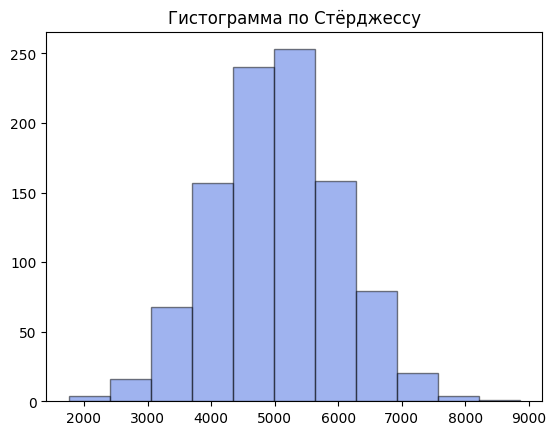

In [ ]:
plt.hist(transactions, bins = k_sturges, color='royalblue', edgecolor='black', alpha=0.5)
plt.title('Гистограмма по Стёрджессу')
plt.show()

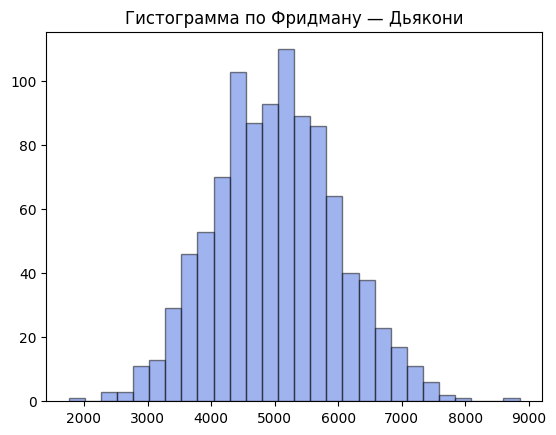

In [ ]:
plt.hist(transactions, bins = k_fd, color='royalblue', edgecolor='black', alpha=0.5)
plt.title('Гистограмма по Фридману — Дьякони')
plt.show()

**Вывод**

В данном случае выбросов не настолько много и они не настолько больше, чтобы формула Стерджесса слишком сильно «огрублялась».

### Пункт 3. Аргумент функции hist для выбора типа бинирования

Аргумент `bins` подразумевает возможность передачи строчного значения.

Прочитай документацию и найди значения аргумента `bins`, которые отвечают за соответствующие типы бинирования.

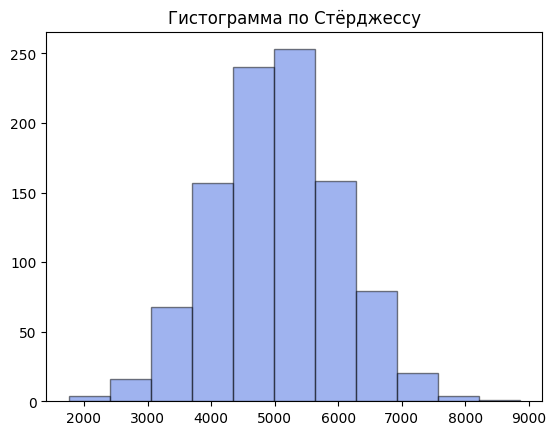

In [ ]:
plt.hist(transactions, bins = 'sturges', color='royalblue', edgecolor='black', alpha=0.5)
plt.title('Гистограмма по Стёрджессу')
plt.show()

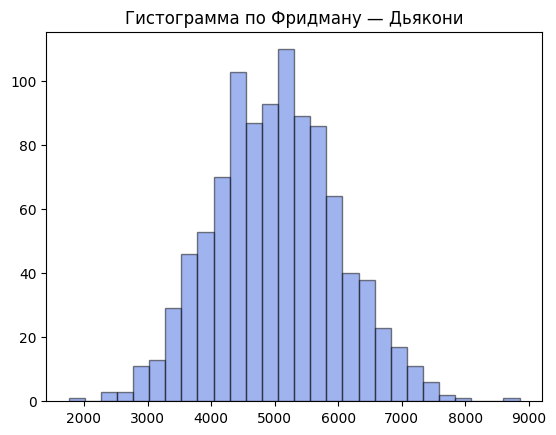

In [ ]:
plt.hist(transactions, bins = 'fd', color='royalblue', edgecolor='black', alpha=0.5)
plt.title('Гистограмма по Фридману — Дьякони')
plt.show()

### Пункт 4. Боксплот

Изобразим боксплот (для разнообразия — по вертикали).

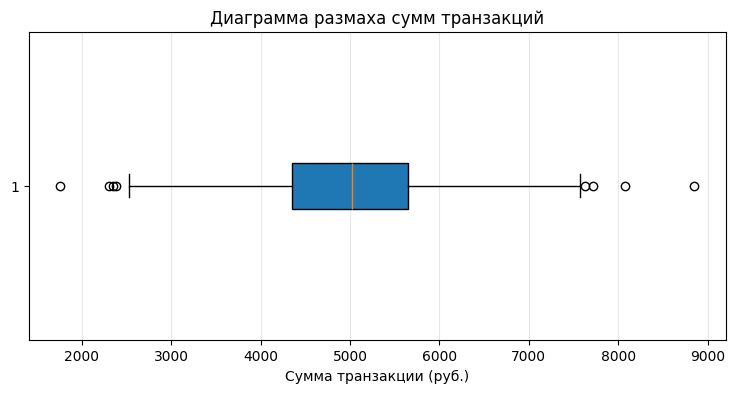

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.boxplot(
    transactions,
    vert=False,
    patch_artist=True
)

ax.set_title('Диаграмма размаха сумм транзакций')
ax.set_xlabel('Сумма транзакции (руб.)')

ax.grid(True, axis='x', alpha=0.3)

plt.show()

### Пункт 5. Построение интервального вариационного ряда

Используя границы интервалов, рассчитаем:
* **срединные значения интервалов** ($x_{mid}$);
* **абсолютные частоты** ($n_i$);
* **относительные частоты** ($w_i$);
* **накопленные частоты** ($m_i$);
* **накопленные относительные частоты** ($W_i$).


In [ ]:
# Создаём границы интервалов на основе сетки Стёрджесса
bins = np.linspace(tx_min, tx_max, k_sturges + 1)

# Группируем транзакции по интервалам с помощью pandas
tx_cut = pd.cut(transactions, bins=bins, right=False, include_lowest=True)
interval_df = pd.DataFrame({'Interval': tx_cut}).groupby('Interval', observed=False).size().reset_index(name='n_i')

# Считаем срединные значения каждого интервала
interval_df['x_mid'] = bins[:-1] + np.diff(bins) / 2

# Считаем относительные частоты
interval_df['w_i'] = interval_df['n_i'] / n_tx

# Считаем накопленные абсолютные частоты
interval_df['m_i'] = interval_df['n_i'].cumsum()

# Считаем накопленные относительные частоты
interval_df['W_i'] = interval_df['w_i'].cumsum()

# Выводим готовую таблицу интервального ряда
interval_df


,Interval,n_i,x_mid,w_i,m_i,W_i
0,"[1758.73, 2403.639)",4,2081.184545,0.004,4,0.004
1,"[2403.639, 3048.548)",16,2726.093636,0.016,20,0.020
2,"[3048.548, 3693.457)",68,3371.002727,0.068,88,0.088
3,"[3693.457, 4338.366)",157,4015.911818,0.157,245,0.245
4,"[4338.366, 4983.275)",240,4660.820909,0.240,485,0.485
5,"[4983.275, 5628.185)",253,5305.730000,0.253,738,0.738
6,"[5628.185, 6273.094)",158,5950.639091,0.158,896,0.896
7,"[6273.094, 6918.003)",79,6595.548182,0.079,975,0.975
8,"[6918.003, 7562.912)",20,7240.457273,0.020,995,0.995
9,"[7562.912, 8207.821)",4,7885.366364,0.004,999,0.999


### Пункт 6. Полигон частот

Фактически полигон частот — это гистограмма в форме линейной функции. Разница заключается в том, что точки находятся в серединах интервалов.


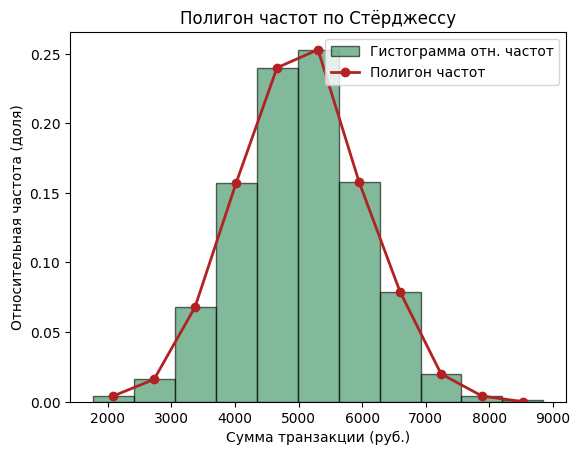

In [ ]:
fig, ax = plt.subplots()

# Веса для построения гистограммы именно относительных частот (долей)
weights = np.ones_like(transactions) / len(transactions)

# Строим гистограмму
ax.hist(transactions, bins=bins, weights=weights, alpha=0.6, color='seagreen', edgecolor='black', label='Гистограмма отн. частот')

# Строим полигон частот (соединяем срединные точки)
ax.plot(interval_df['x_mid'], interval_df['w_i'], color='firebrick', marker='o', linestyle='-', linewidth=2, label='Полигон частот')

ax.set_title('Полигон частот по Стёрджессу')
ax.set_xlabel('Сумма транзакции (руб.)')
ax.set_ylabel('Относительная частота (доля)')
ax.legend()

plt.show()


К сожалению, у функции `hist` нет аргумента, который превращал бы гистограмму в полигон частот, есть лишь возможность получить ступенчатый контур с помощью аргумента `histtype`.

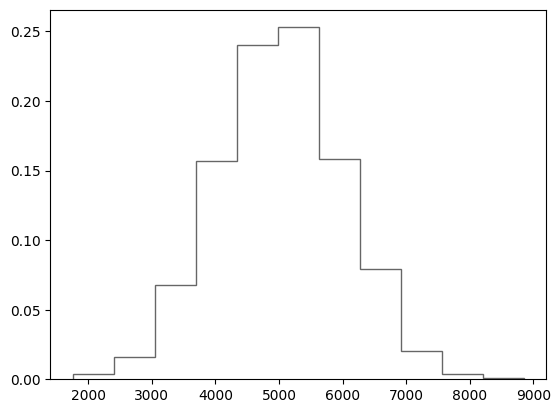

In [ ]:
plt.hist(transactions, bins=bins, weights=weights, alpha=0.6, histtype='step',
        color='seagreen', edgecolor='black', label='Гистограмма отн. частот')
plt.show()

### Пункт 7. Кумулята и огива

Огива и кумулята — это функции, отражающие накопление частостей с ростом значения признака. Разница между ними чаще всего заключается в том, что оси $X$ и $Y$ меняются местами.

С помощью функции выражения `np.r_` мы можем объединять массивы. В данном случае добавляем левую границу для начальной точки огивы.

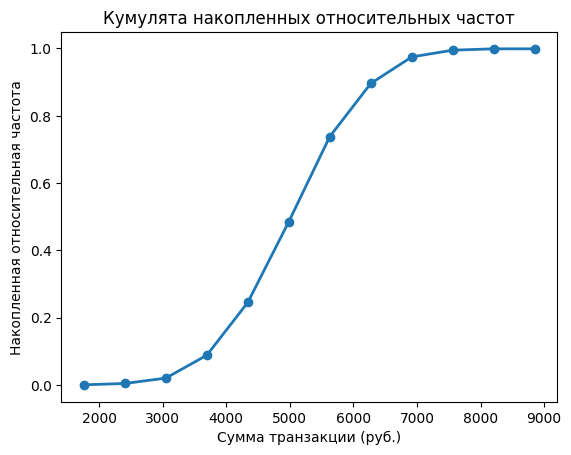

In [ ]:
# Добавляем левую границу первого интервала для начала огивы
ogive_x = bins
ogive_y = np.r_[0, interval_df['W_i']]

plt.plot(ogive_x, ogive_y, marker='o', linewidth=2)
plt.title('Кумулята накопленных относительных частот')
plt.xlabel('Сумма транзакции (руб.)')
plt.ylabel('Накопленная относительная частота')
plt.show()

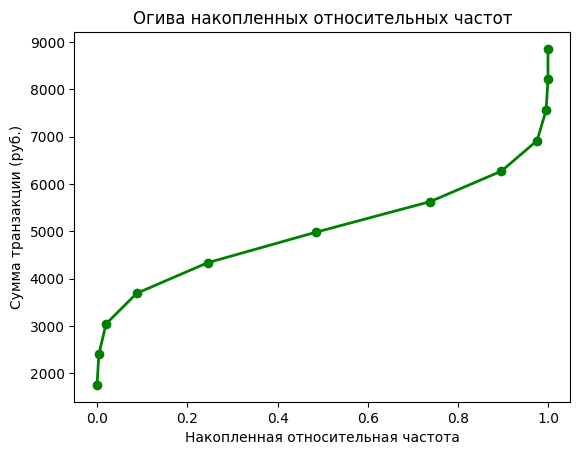

In [ ]:
# Добавляем левую границу первого интервала для начала огивы
ogive_x = bins
ogive_y = np.r_[0, interval_df['W_i']]

plt.plot(ogive_y, ogive_x, marker='o', linewidth=2, color='green')
plt.title('Огива накопленных относительных частот')
plt.xlabel('Накопленная относительная частота')
plt.ylabel('Сумма транзакции (руб.)')
plt.show()